# MEAI 502 — Applied Machine Learning
### Lab 2 · Training and Evaluating Your First Model

Dr. Naila Marir · College of Engineering, Effat University · Fall 2026

---

In Lab 1 you framed a problem and got to know a dataset. Today you turn it into a model — and,
more importantly, into a number you could defend to a clinician.

**The goal of this lab:** take the data you explored in Lab 1 through stages 4, 5 and 6 — prepare it,
train a model on it, and measure it honestly.

| | |
|---|---|
| **Prerequisites** | Lab 1 completed. You should be able to say what *recall* is and why we chose it. |
| **Deliverable** | This notebook with both `# TODO` cells completed, renamed `MEAI502_Lab2_<YourName>.ipynb`, on Blackboard. |
| **Assessment** | Exercise 60 %, reflection 40 %. See Part 5. |

This notebook is self-contained — it reloads the data itself, so you do not need Lab 1 open.

---
# Part 1 — Where We Left Off
*≈ 10 minutes*

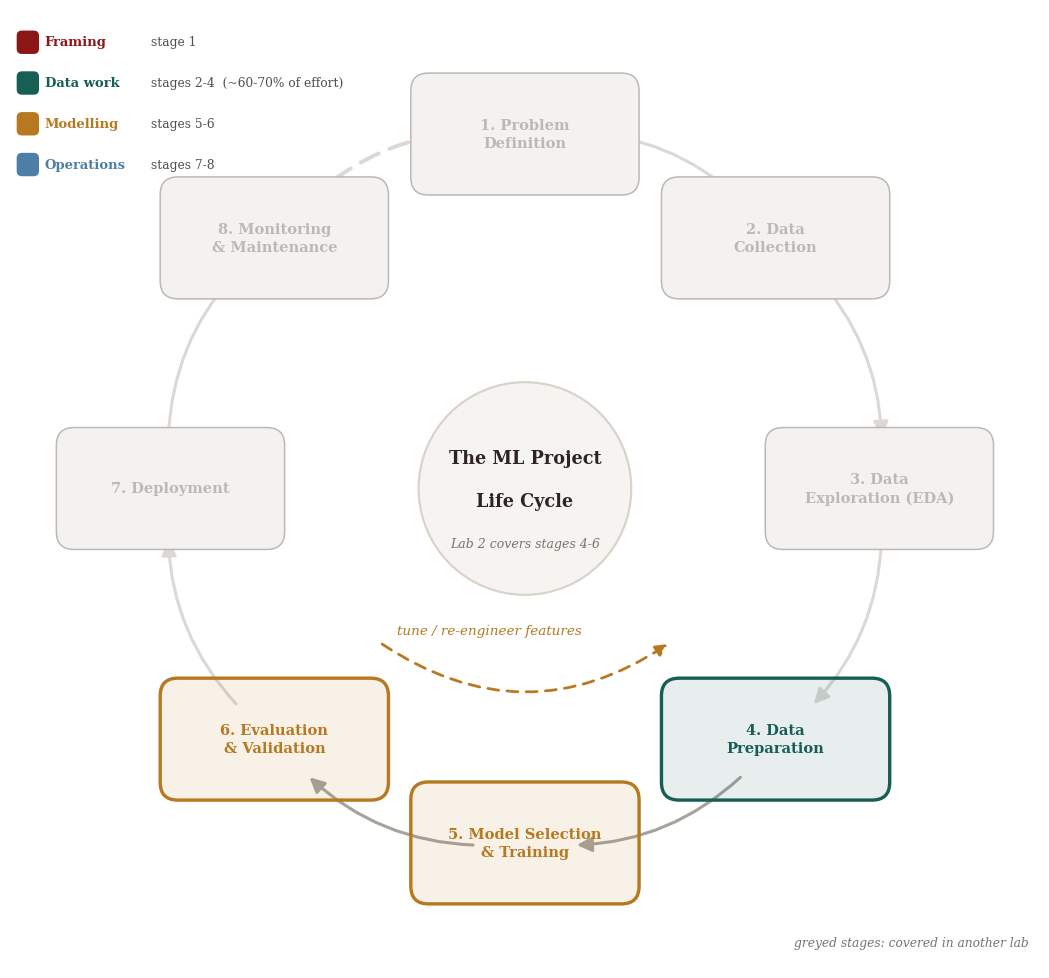

**Stage 1 (done in Lab 1).** Flag biopsies likely to be malignant so a radiologist reviews them first.
Binary classification. `y`: 1 = malignant, 0 = benign. **Metric: recall on the malignant class** —
of all the truly malignant cases, what fraction do we catch?

**Stages 2 and 3 (done in Lab 1).** 569 biopsies, 30 numeric features, no missing values,
37.3 % malignant, several features that clearly separate the two classes — and **wildly different
scales** between columns. That last one becomes today's problem.

In [ ]:
# Setup, and the same house style as Lab 1.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = ["#8C1515", "#4D7EA8", "#175E54", "#B7791F"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
print("ready")

In [ ]:
# Reload the data exactly as we left it in Lab 1.
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X = data.data
y = (data.target == 0).astype(int)      # 1 = malignant, 0 = benign
y.name = "malignant"

print("samples :", X.shape[0])
print("features:", X.shape[1])
print(f"malignant rate: {y.mean():.1%}")

---
# Part 2 — Stage 4: Data Preparation
*≈ 35 minutes*

Stage 4 has two jobs today, and both matter more than which model you eventually pick:

1. **Split** the data, so you keep an honest test set.
2. **Scale** the features, so the model can use them — without letting the test set influence training.

Get either wrong and every number you report afterwards is fiction.

## 4.1 Split first

You need data the model has never seen, to estimate how it will behave on patients it has never seen.
So: hold some out now, before you touch anything else.

Two arguments do real work here:

- **`stratify=y`** keeps the malignant rate the same in both halves. Without it, a random split can
  hand you a test set with a different mix than the training set — and then you are measuring the
  wrong population.
- **`random_state=42`** makes the split repeatable. Any fixed number works; the point is that you and
  I get the same rows.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("train:", X_train.shape[0], "samples")
print("test :", X_test.shape[0], "samples")

Check that `stratify` did what it promised:

In [ ]:
print(f"malignant rate, whole dataset: {y.mean():.1%}")
print(f"malignant rate, training set : {y_train.mean():.1%}")
print(f"malignant rate, test set     : {y_test.mean():.1%}")

Close enough to identical. Now a rule for the rest of the lab:

> **The test set is sealed.** We do not look at it, fit anything on it, or make any decision based on
> it until Part 4. Every time you peek at the test set and then change something, a little knowledge
> leaks into your choices and your final number becomes optimistic.

## 4.2 The scale problem

Remember what we noticed in Lab 1: these columns live on completely different scales. Look again.

In [ ]:
X_train[["mean area", "mean concavity", "mean texture"]].describe().round(2).loc[["mean", "std"]]

`mean area` has a standard deviation in the hundreds; `mean concavity` has one below 0.1 — a
difference of roughly four orders of magnitude.

Logistic regression learns one weight per feature and adds them up. If one feature arrives a thousand
times larger than another, it dominates that sum for a reason that has nothing to do with the biology.
So we put every feature on the same footing: **subtract the mean, divide by the standard deviation.**
That is what `StandardScaler` does.

## 4.3 Scale — but fit on the training set only

This is the part to get exactly right.

- **`fit_transform(X_train)`** — *learn* each column's mean and standard deviation from the training
  rows, then apply them.
- **`transform(X_test)`** — apply **those same numbers** to the test rows. Do not re-learn them.

Why it matters: if you learned the mean from the whole dataset, that mean would contain the test rows.
Information from the test set would reach the training data — **data leakage** — and your reported
score would go *up* while your model got *worse*. It does not crash and it does not warn you, which
is exactly why it is the most common bug in student projects.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # LEARN from train, then apply
X_test_scaled  = scaler.transform(X_test)        # APPLY the same numbers to test

print("shapes unchanged:", X_train_scaled.shape, X_test_scaled.shape)

Look at what changed. Every training column now has mean 0 and standard deviation 1:

In [ ]:
scaled_train = pd.DataFrame(X_train_scaled, columns=X.columns)
print("TRAINING set, after scaling:")
print(scaled_train[["mean area", "mean concavity", "mean texture"]]
      .describe().round(3).loc[["mean", "std"]])

In [ ]:
scaled_test = pd.DataFrame(X_test_scaled, columns=X.columns)
print("TEST set, after scaling with the TRAINING set's numbers:")
print(scaled_test[["mean area", "mean concavity", "mean texture"]]
      .describe().round(3).loc[["mean", "std"]])

Notice the test set's means are **not** exactly 0, and its standard deviations are **not** exactly 1.

That is not a bug — it is the whole point. The test set was transformed using numbers learned
somewhere else, which is precisely the situation a deployed model faces: a new patient arrives and you
scale them with the numbers you learned months ago in training. If the test means *had* come out at
exactly 0, it would mean you had leaked.

---
# Part 3 — Stage 5: Training
*≈ 25 minutes*

## 5.1 The baseline comes first

Before any real model: what does a *trivial* model score? `DummyClassifier` with
`strategy="most_frequent"` always predicts the majority class — here, always "benign".

This is the number your real model has to beat. Without it, "96 % accurate" means nothing at all.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_scaled, y_train)

baseline_pred = baseline.predict(X_test_scaled)

print("BASELINE - always predicts benign")
print(f"  accuracy: {accuracy_score(y_test, baseline_pred):.3f}")
print(f"  recall  : {recall_score(y_test, baseline_pred):.3f}")

There it is: **63 % accurate, and it catches nothing.** Zero recall. Every malignant case in the
test set walks straight past it.

If you only ever reported accuracy, this model would look like a reasonable start. That is the trap
Lab 1 warned you about, made concrete.

## 5.2 The real model

`LogisticRegression` is a linear classifier: it learns one weight per feature, adds them up, and turns
the total into a probability between 0 and 1. It is simple, fast, and — importantly for a medical
tool — you can look at the weights and see what it is doing.

Two lines. This is the part everyone thinks machine learning *is*.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

print("trained")

In [ ]:
y_pred = model.predict(X_test_scaled)

print("first 15 predictions:", y_pred[:15])
print("first 15 true labels:", y_test.values[:15])

Most of them match. Now the real question of this lab: **how do we say how good that is, in a way
a clinician would accept?**

---
# Part 4 — Stage 6: Evaluation
*≈ 35 minutes*

## 6.1 Start with accuracy, then stop trusting it

In [ ]:
print(f"accuracy: {accuracy_score(y_test, y_pred):.3f}")

96.5 %, against a baseline of 62.9 %. Genuinely good — the model has learned something real.

But accuracy tells you *how many* mistakes, never *which*. Our two mistakes are not equal: one costs
a review, the other costs a life. So accuracy cannot be the last word.

## 6.2 The confusion matrix

The confusion matrix breaks the errors apart. Four numbers, and they are the foundation of every
classification metric you will ever use.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.2, 3.8))
ConfusionMatrixDisplay(cm, display_labels=["benign", "malignant"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (test set)")
ax.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

print(f"true negatives  (TN) {tn:3d}   benign, called benign")
print(f"false positives (FP) {fp:3d}   benign, wrongly flagged   -> one extra review")
print(f"false negatives (FN) {fn:3d}   MALIGNANT, missed         -> the expensive error")
print(f"true positives  (TP) {tp:3d}   malignant, caught")

Sit with those four numbers for a moment. **Four malignant cases were missed.** That is what
"96.5 % accuracy" was hiding.

## 6.3 Recall and precision, by hand

Both come straight out of the four numbers above. Compute them yourself once — after that you can use
the library function and know what it means.

$$\text{recall} = \frac{TP}{TP + FN} \qquad \text{precision} = \frac{TP}{TP + FP}$$

- **Recall** answers: *of all the truly malignant cases, how many did we catch?*
- **Precision** answers: *of all the cases we flagged, how many really were malignant?*

In [ ]:
recall_by_hand    = tp / (tp + fn)
precision_by_hand = tp / (tp + fp)

print(f"recall    = {tp} / ({tp} + {fn}) = {recall_by_hand:.3f}")
print(f"precision = {tp} / ({tp} + {fp}) = {precision_by_hand:.3f}")

In [ ]:
# The same numbers, from the library.
from sklearn.metrics import precision_score

print(f"recall_score   : {recall_score(y_test, y_pred):.3f}")
print(f"precision_score: {precision_score(y_test, y_pred):.3f}")

## 6.4 The full report

`classification_report` gives you both classes at once. Read the **malignant** row.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["benign", "malignant"]))

### The verdict

Say it the way you would say it to the pathology lab:

> *On 143 biopsies it had never seen, the tool caught **92.5 %** of the malignant cases. Of the cases
> it flagged, **98 %** really were malignant, so it creates very few unnecessary reviews. It missed
> **4** malignant cases out of 53.*

That is a defensible statement: a metric that matches the decision, a number, and an honest account of
what it costs. Compare it to "96.5 % accurate", which is true, higher, and tells the lab nothing they
need.

**Is 92.5 % good enough?** That is not a question you answer alone — it is a conversation with the
clinicians about what a miss costs. There are also ways to trade precision for recall, and better ways
to check whether this number is stable. Both come in later labs.

---
# Stages 7 and 8 — what happens next
*≈ 10 minutes, no code*

You have a model that works on a sealed test set. Two stages stand between that and something a
hospital can use.

**Stage 7 — Deployment.** The model gets saved and served where the decision is made. One rule
matters more than the rest: **the scaler has to travel with the model.** Your model was trained on
scaled numbers, so production must scale incoming patients with *exactly* the numbers in
`scaler` — not re-learned, not skipped. Get that wrong and the model answers confidently and wrongly,
with nothing crashing to tell you. It is called *training/serving skew*, and it is the most expensive
bug in this whole course.

**Stage 8 — Monitoring.** Models decay, because the world moves. A new scanner, a units change
upstream, a different patient population — and the incoming data stops looking like the training data.
That shows up in the *distribution of your predictions* long before anyone reports a wrong diagnosis,
which is why you watch it. When you detect it, you collect fresh ground truth and decide whether to
retrain — and that decision sends you all the way back to Stage 1.

That is the red dashed arrow in the life-cycle diagram, and it is why the diagram is a circle.

---
# Part 5 — Wrap-up
*≈ 15 minutes*

## Exercise — a second model, and a decision  *(60 %)*

A `DecisionTreeClassifier` works completely differently: instead of weighting features, it asks a
series of yes/no questions. `max_depth=3` allows it only three questions deep, which makes it simple
enough to draw on a whiteboard for a clinician.

1. Train one on `X_train_scaled`, `y_train`.
2. Predict on `X_test_scaled`.
3. Print its accuracy, recall and precision, next to the logistic regression's.
4. In two or three sentences: **which one would you deploy, and why?** Think about recall, about the
   four missed cases, and about what you would have to explain to the pathology lab.

The marks are in step 4.

In [ ]:
# TODO 1 - the second model.

from sklearn.tree import DecisionTreeClassifier

# 1) train it
tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
# tree.fit(...)

# 2) predict on the test set
# tree_pred = ...

# 3) print accuracy, recall and precision for BOTH models


# 4) Your answer, in a comment of 2-3 sentences:
# WHICH MODEL WOULD YOU DEPLOY, AND WHY?
# Answer: ...

## Reflection — explain it to the clinician  *(40 %)*

The pathology lab has no machine learning background. In plain language — no formulas, no jargon —
answer three questions about the model you just built.

Imagine you are writing three sentences in an email, not an exam answer.

In [ ]:
# TODO 2 - three plain-language sentences. No jargon.

to_the_clinician = {
    "what_it_does":  "...",   # what does the tool do, in one sentence a doctor would accept?
    "how_good":      "...",   # how well does it work? quote a number and say what it means
    "what_it_costs": "...",   # what does it get wrong, and what happens when it does?
}

for question, answer in to_the_clinician.items():
    print(f"{question:14}: {answer}\n")
    assert answer != "...", f"Still to do: {question}" 

## Before you submit

1. `Runtime → Restart and run all` — the whole notebook must run top to bottom without errors.
2. `File → Download → .ipynb`, rename it `MEAI502_Lab2_<YourName>.ipynb`.
3. Upload it to Blackboard.

---

## Next lab — **NumPy**

You have now used the whole stack without ever looking underneath it. Lab 3 goes one layer down, to
the library everything else is built on:

- Creating arrays; `dtype`, `shape`, `ndim`, and why they matter
- Indexing, slicing, boolean masks
- **Vectorisation** — replacing loops with expressions, and the speed difference
- **Broadcasting** — the rule that lets a `(3,1)` array meet a `(1,4)` array
- Aggregations along axes; reshaping and stacking
- Why a pandas DataFrame is really a set of NumPy arrays wearing labels

**Before Lab 3:** skim the NumPy absolute beginner's guide —
https://numpy.org/doc/stable/user/absolute_beginners.html

---

### References

1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed.), Ch. 3.
2. scikit-learn user guide — https://scikit-learn.org/stable/user_guide.html
3. scikit-learn — *Metrics and scoring* — https://scikit-learn.org/stable/modules/model_evaluation.html
4. Dua, D. & Graff, C. — UCI Machine Learning Repository, *Breast Cancer Wisconsin (Diagnostic)*.

---
*MEAI 502 Applied Machine Learning — Lab 2 — Dr. Naila Marir — Effat University, Fall 2026*